## TP de Machine Learning — Apprentissage Non Supervisé
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente **2 algorithmes d'apprentissage non supervisé** :
1. **DBSCAN** — Clustering par densité
2. **PCA** — Analyse en Composantes Principales

Chaque algorithme est comparé entre une implémentation **From Scratch** et **Scikit-Learn**.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

### IMPLÉMENTATIONS FROM SCRATCH

In [2]:
class DBSCANFromScratch:
    """DBSCAN implémenté manuellement — clustering basé sur la densité."""
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps; self.min_samples = min_samples; self.labels_ = None
    def _region_query(self, X, idx):
        return np.where(np.sqrt(np.sum((X - X[idx])**2, axis=1)) <= self.eps)[0]
    def fit_predict(self, X):
        n = len(X); self.labels_ = np.full(n, -1); cluster_id = 0; visited = np.zeros(n, dtype=bool)
        for i in range(n):
            if visited[i]: continue
            visited[i] = True; neighbors = self._region_query(X, i)
            if len(neighbors) < self.min_samples: continue
            self.labels_[i] = cluster_id; seeds = list(neighbors); j = 0
            while j < len(seeds):
                q = seeds[j]
                if not visited[q]:
                    visited[q] = True; q_nb = self._region_query(X, q)
                    if len(q_nb) >= self.min_samples: seeds.extend(q_nb)
                if self.labels_[q] == -1: self.labels_[q] = cluster_id
                j += 1
            cluster_id += 1
        return self.labels_

class PCAFromScratch:
    """Analyse en Composantes Principales implémentée manuellement."""
    def __init__(self, n_components=2):
        self.n_components = n_components; self.components = None; self.mean = None
    def fit(self, X):
        self.mean = np.mean(X, axis=0); Xc = X - self.mean
        cov = np.cov(Xc.T); eigvals, eigvecs = np.linalg.eigh(cov)
        idx = np.argsort(eigvals)[::-1]; self.components = eigvecs[:, idx[:self.n_components]]
        self.explained_variance_ratio_ = eigvals[idx[:self.n_components]] / np.sum(eigvals)
        return self
    def transform(self, X): return (X - self.mean).dot(self.components)

### PRÉPARATION DES DONNÉES

In [3]:
df = pd.read_csv('data/medical_costs.csv')
X_class = df[['age', 'bmi']].values
X_multi = df[['age', 'bmi', 'children']].values
median_cost = np.median(df['cost'].values)
y_class = (df['cost'].values >= median_cost).astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_class)
print(f"Échantillons : {len(df)}")

Échantillons : 500


### TEST 1 : DBSCAN (Clustering par Densité)
DBSCAN regroupe les points qui sont **densément connectés** et identifie les points isolés comme du **bruit** (-1). Contrairement à K-Means, il ne nécessite pas de spécifier le nombre de clusters.

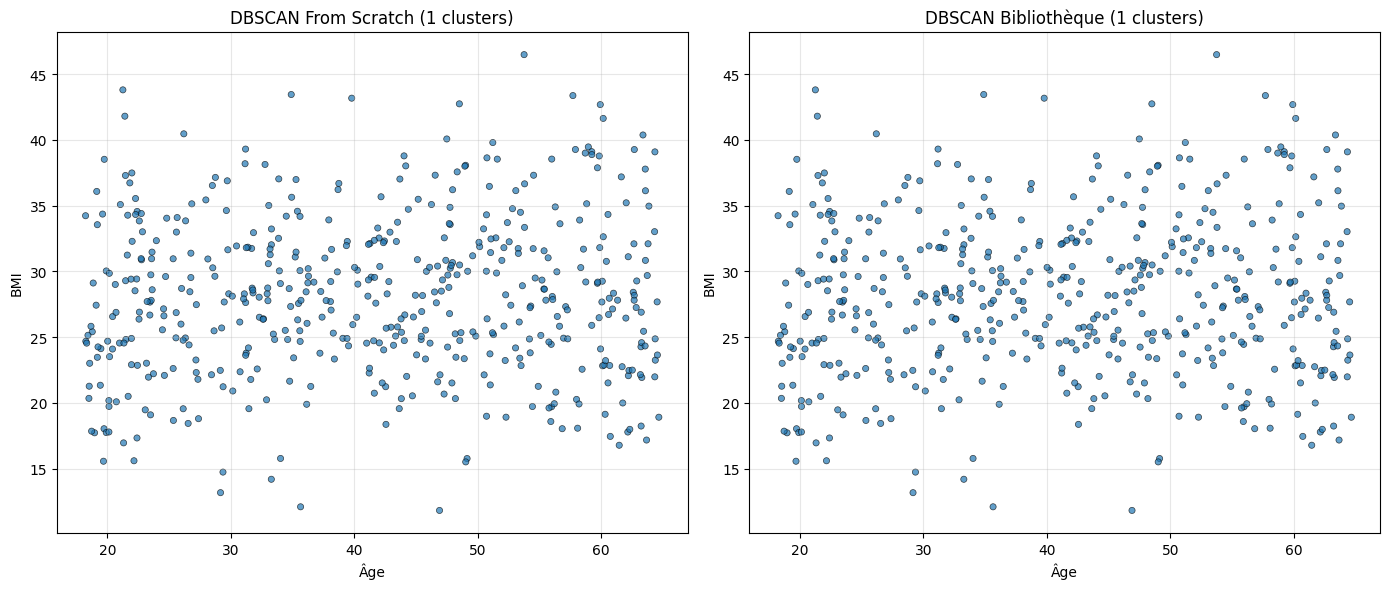

In [4]:
db_scratch = DBSCANFromScratch(eps=0.8, min_samples=5)
labels_scratch = db_scratch.fit_predict(X_scaled)
db_sklearn = SklearnDBSCAN(eps=0.8, min_samples=5)
labels_sklearn = db_sklearn.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_class[:,0], X_class[:,1], c=labels_scratch, cmap='tab10', s=20, alpha=0.7, edgecolors='black', linewidths=0.5)
ax1.set_title(f'DBSCAN From Scratch ({len(set(labels_scratch)-{-1})} clusters)')
ax1.set_xlabel('Âge'); ax1.set_ylabel('BMI'); ax1.grid(True, alpha=0.3)
ax2.scatter(X_class[:,0], X_class[:,1], c=labels_sklearn, cmap='tab10', s=20, alpha=0.7, edgecolors='black', linewidths=0.5)
ax2.set_title(f'DBSCAN Bibliothèque ({len(set(labels_sklearn)-{-1})} clusters)')
ax2.set_xlabel('Âge'); ax2.set_ylabel('BMI'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### TEST 2 : PCA (Analyse en Composantes Principales)
PCA réduit la dimensionnalité des données en trouvant les **axes de variance maximale**. On projette ici 3 variables (âge, BMI, enfants) sur 2 composantes principales.

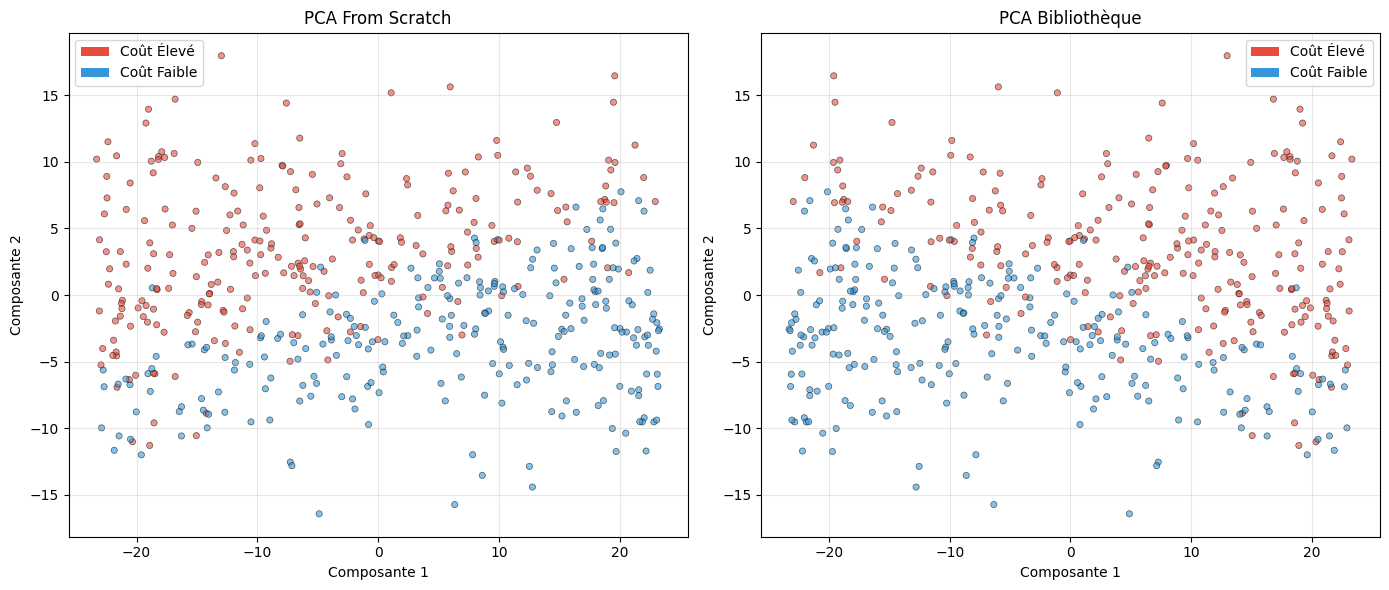

In [5]:
pca_scratch = PCAFromScratch(n_components=2); pca_scratch.fit(X_multi)
X_pca_scratch = pca_scratch.transform(X_multi)
pca_sklearn = SklearnPCA(n_components=2); pca_sklearn.fit(X_multi)
X_pca_sklearn = pca_sklearn.transform(X_multi)
colors = np.where(y_class==1, '#e74c3c', '#3498db')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(X_pca_scratch[:,0], X_pca_scratch[:,1], c=colors, s=20, alpha=0.6, edgecolors='black', linewidths=0.5)
ax1.set_title('PCA From Scratch'); ax1.set_xlabel('Composante 1'); ax1.set_ylabel('Composante 2'); ax1.grid(True, alpha=0.3)
ax2.scatter(X_pca_sklearn[:,0], X_pca_sklearn[:,1], c=colors, s=20, alpha=0.6, edgecolors='black', linewidths=0.5)
ax2.set_title('PCA Bibliothèque'); ax2.set_xlabel('Composante 1'); ax2.set_ylabel('Composante 2'); ax2.grid(True, alpha=0.3)
for ax in [ax1,ax2]: ax.legend(handles=[Patch(facecolor='#e74c3c',label='Coût Élevé'),Patch(facecolor='#3498db',label='Coût Faible')])
plt.tight_layout(); plt.show()